In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [71]:
project1 = pd.read_csv(r"C:\Users\Akshay\Downloads\noisy_dataset_1000_rows.csv")
project1.head()

,id,name,age,salary,joining_date,is_active,city,rating,experience_years,email,phone,status
0,0.0,Unknown,56,NaN,2024-08-08 00:00:00,False,Bangalore,4.8,10,user0@example.com,1.670095e+09,unknown
1,1.0,Ravi,36,unknown,2018-05-23 00:00:00,True,?,1.2,3,user1@example.com,9.678344e+09,unknown
2,2.0,Unknown,19,113859.84,2024-07-17 00:00:00,True,Bangalore,10,5,user2@example.com,6.075900e+09,Inactive
3,3.0,Amit,38,100272.6,2024-04-08 00:00:00,Yes,Pune,3.1,11,user3@example.com,2.250820e+09,Inactive
4,4.0,NaN,44,99540.88,2025-04-11 00:00:00,True,Delhi,1.2,15,user4@example.com,NaN,unknown


In [72]:
project1.shape

(1000, 12)

In [73]:
project1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                962 non-null    float64
 1   name              783 non-null    str    
 2   age               974 non-null    str    
 3   salary            894 non-null    str    
 4   joining_date      951 non-null    str    
 5   is_active         793 non-null    str    
 6   city              736 non-null    str    
 7   rating            927 non-null    str    
 8   experience_years  964 non-null    str    
 9   email             864 non-null    str    
 10  phone             875 non-null    float64
 11  status            794 non-null    str    
dtypes: float64(2), str(10)
memory usage: 93.9 KB


In [74]:
project1.describe()

,id,phone
count,962.00000,8.750000e+02
mean,500.41580,4.957875e+09
std,289.21322,2.852980e+09
min,0.00000,1.234500e+04
25%,249.25000,2.651547e+09
50%,499.50000,4.867266e+09
75%,751.75000,7.357849e+09
max,999.00000,9.998007e+09


In [75]:
project1.isnull().sum()

id                   38
name                217
age                  26
salary              106
joining_date         49
is_active           207
city                264
rating               73
experience_years     36
email               136
phone               125
status              206
dtype: int64

In [76]:
project1 = project1.drop(columns=["id","email","phone","name" ,"joining_date"])

In [77]:
num_cols = ["age", "salary","rating","experience_years"]

for cols in num_cols:
    project1[cols]= pd.to_numeric(project1[cols], errors="coerce")

In [78]:
for cols in num_cols:
    project1[cols] = project1[cols].fillna(project1[cols].mean())

In [79]:
cat_cols = ["city","status"]
for cols in cat_cols:
    project1[cols] = project1[cols].fillna(project1[cols].mode())

In [80]:
project1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1000 non-null   float64
 1   salary            1000 non-null   float64
 2   is_active         793 non-null    str    
 3   city              736 non-null    str    
 4   rating            1000 non-null   float64
 5   experience_years  1000 non-null   float64
 6   status            794 non-null    str    
dtypes: float64(4), str(3)
memory usage: 54.8 KB


In [81]:
project1.isnull().sum()

age                   0
salary                0
is_active           207
city                264
rating                0
experience_years      0
status              206
dtype: int64

In [82]:
project1["is_active"] = project1["is_active"].fillna(project1["is_active"].mode()[0])

In [83]:
project1["city"] = project1["city"].fillna(project1["city"].mode()[0])
project1["status"]= project1["status"].fillna(project1["status"].mode()[0])

In [84]:
project1.isnull().sum()

age                 0
salary              0
is_active           0
city                0
rating              0
experience_years    0
status              0
dtype: int64

In [85]:
print(project1)

      age        salary is_active       city     rating  experience_years  \
0    56.0   84600.73847     False  Bangalore   4.800000         10.000000   
1    36.0   84600.73847      True          ?   1.200000          3.000000   
2    19.0  113859.84000      True  Bangalore  10.000000          5.000000   
3    38.0  100272.60000       Yes       Pune   3.100000         11.000000   
4    44.0   99540.88000      True      Delhi   1.200000         15.000000   
..    ...           ...       ...        ...        ...               ...   
995  32.0   84600.73847      True      Delhi   4.300000         16.000000   
996  53.0   87248.15000       Yes          ?   3.496366          9.038085   
997  43.0   61093.17000      True       Pune   3.496366          4.000000   
998  58.0   30475.51000       Yes     Mumbai   1.800000          0.000000   
999  34.0   84600.73847        No       Pune   3.496366          4.000000   

       status  
0     unknown  
1     unknown  
2    Inactive  
3    Inacti

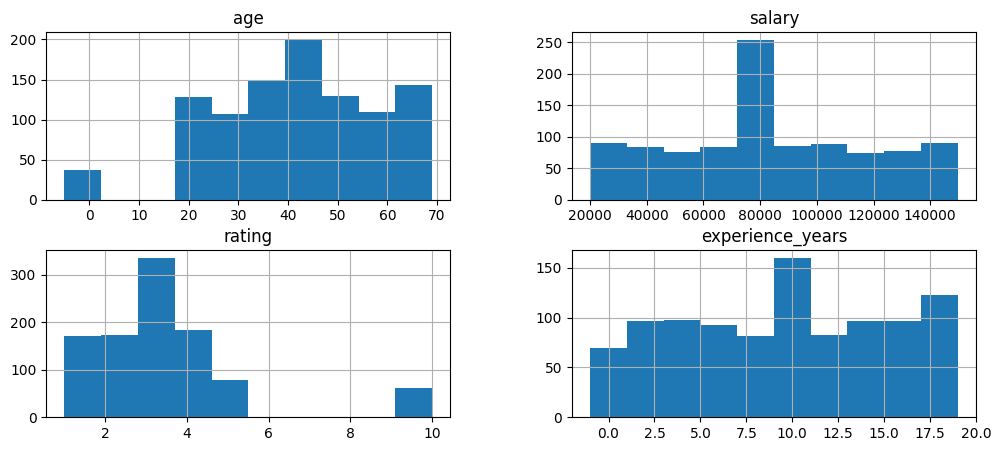

In [86]:
project1.hist(figsize=(12,5))
plt.show()

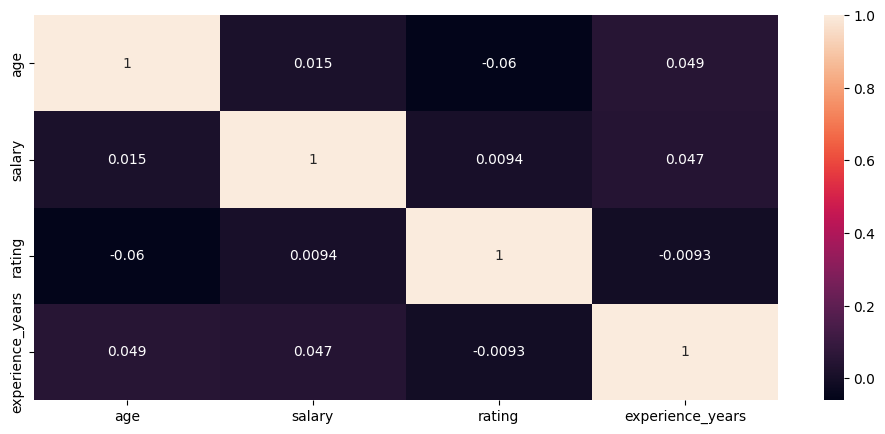

In [89]:
import seaborn as sns
plt.figure(figsize=(12,5))
sns.heatmap(project1.select_dtypes(include=['number']).corr(), annot=True)
plt.show()

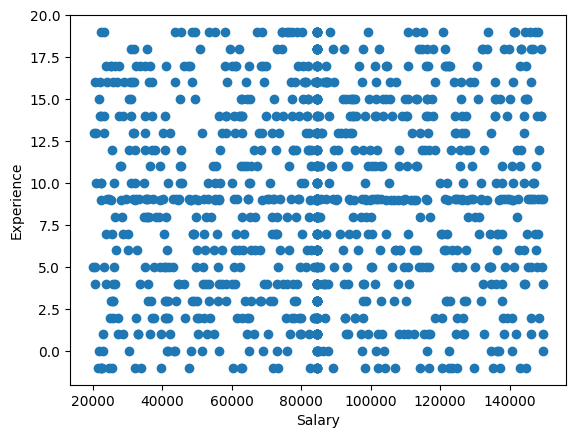

In [91]:
plt.scatter(project1["salary"],project1["experience_years"])
plt.xlabel("Salary")
plt.ylabel("Experience")
plt.show()

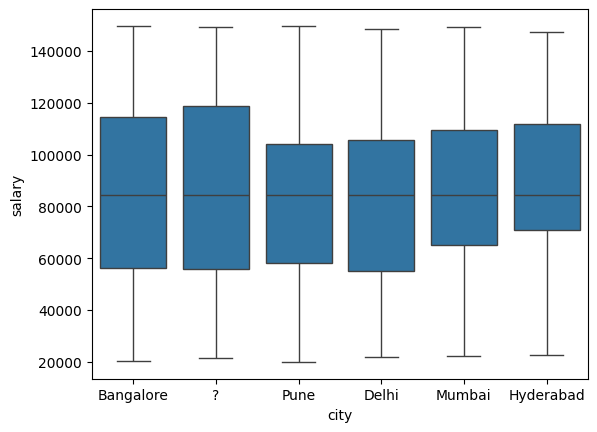

In [94]:
sns.boxplot(x="city",y="salary",data=project1)
plt.show()